In [1]:
import numpy as np  
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

from utils import set_pretty_prints, load_dataset

In [2]:
set_pretty_prints()

In [3]:
df = load_dataset('imobiliare.ro')

In [4]:
df

,Unnamed: 0,nr cam,mp,parter,et1-2,et3+,etaj max,typ_decom,bloc nou,Price/Surface,Price,WebPage
0,1,2,56.00,0,1,0,2,1,1,639.29,35800,https://www.imobiliare.ro/vanzare-apartamente/bucuresti/rahova/apartament-de-vanzare-2-camere-XAU700006?lista=2349706&listing=1
1,2,2,57.00,0,1,0,2,0,1,628.07,35800,https://www.imobiliare.ro/vanzare-apartamente/bucuresti/rahova/apartament-de-vanzare-2-camere-XAG00001O?lista=2349706&listing=1
2,3,2,67.00,0,1,0,2,1,1,591.04,39600,https://www.imobiliare.ro/vanzare-apartamente/bucuresti/rahova/apartament-de-vanzare-2-camere-XAG00001K?lista=2349706&listing=1
3,4,1,48.00,0,1,0,2,1,1,620.83,29800,https://www.imobiliare.ro/vanzare-garsoniere/bucuresti/rahova/garsoniera-de-vanzare-XAG00001J?lista=2349706&listing=1
4,5,3,89.60,0,0,1,3,1,1,1260.04,112900,https://www.imobiliare.ro/vanzare-apartamente/bucuresti/p-ta-presei-libere/apartament-de-vanzare-3-camere-XB0V00003?lista=2349706&listing=1
...,...,...,...,...,...,...,...,...,...,...,...,...
9892,9894,4,90.00,0,0,1,8,0,0,944.44,85000,https://www.imobiliare.ro/vanzare-apartamente/bucuresti/crangasi/apartament-de-vanzare-4-camere-X5LL10023?lista=2349706&listing=1
9893,9895,3,85.00,0,0,1,8,1,0,1588.22,134999,https://www.imobiliare.ro/vanzare-apartamente/bucuresti/central/apartament-de-vanzare-3-camere-X9I6100JP?lista=2349706&listing=1
9894,9896,2,48.00,0,0,1,4,0,0,1229.17,59000,https://www.imobiliare.ro/vanzare-apartamente/bucuresti/apusului/apartament-de-vanzare-2-camere-XBJG000HP?lista=2349706&listing=1
9895,9897,4,83.81,0,0,1,3,1,1,1312.49,110000,https://www.imobiliare.ro/vanzare-apartamente/bucuresti/theodor-pallady/penthouse-de-vanzare-4-camere-XANO10193?lista=2349706&listing=1


In [5]:
y_price = df["Price"]

X = df.iloc[:, 1:9]


In [6]:
y_price

0        35800
1        35800
2        39600
3        29800
4       112900
         ...  
9892     85000
9893    134999
9894     59000
9895    110000
9896     61500
Name: Price, Length: 9897, dtype: int64

In [7]:
X

,nr cam,mp,parter,et1-2,et3+,etaj max,typ_decom,bloc nou
0,2,56.00,0,1,0,2,1,1
1,2,57.00,0,1,0,2,0,1
2,2,67.00,0,1,0,2,1,1
3,1,48.00,0,1,0,2,1,1
4,3,89.60,0,0,1,3,1,1
...,...,...,...,...,...,...,...,...
9892,4,90.00,0,0,1,8,0,0
9893,3,85.00,0,0,1,8,1,0
9894,2,48.00,0,0,1,4,0,0
9895,4,83.81,0,0,1,3,1,1


# Exploration of data

In [8]:
def plot_feature_distrib(name, log=False):
    plt.figure(figsize=(8, 5))
    plt.hist(df[name], bins=30, color='skyblue', edgecolor='black', log=log)
    plt.title(f'Distribution of {name}')
    plt.xlabel(name)
    plt.grid()
    plt.show()

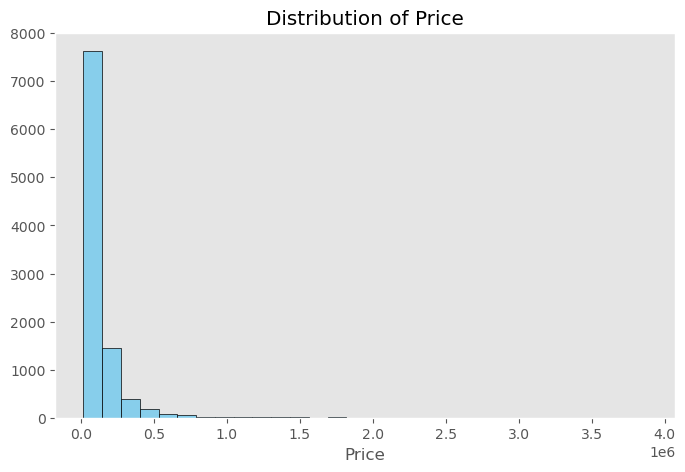

In [9]:
plot_feature_distrib("Price")


In [10]:
y_price.describe()


count    9.897000e+03
mean     1.349255e+05
std      1.781450e+05
min      1.800000e+04
25%      6.350000e+04
50%      8.715000e+04
75%      1.390000e+05
max      3.880000e+06
Name: Price, dtype: float64

In [11]:
df[df["Price"]>=3e6]

,Unnamed: 0,nr cam,mp,parter,et1-2,et3+,etaj max,typ_decom,bloc nou,Price/Surface,Price,WebPage
1914,1915,5,350.00,0,0,1,6,1,0,8571.43,3000000,https://www.imobiliare.ro/vanzare-apartamente/bucuresti/herastrau/penthouse-de-vanzare-5-camere-X2F71004A?lista=2349706&listing=1
2947,2948,4,322.00,0,0,1,5,1,1,12049.69,3880000,https://www.imobiliare.ro/vanzare-apartamente/bucuresti/herastrau/penthouse-de-vanzare-4-camere-X9V60003Q?lista=2349706&listing=1
7755,7756,5,160.73,0,0,1,5,0,1,20531.33,3300000,https://www.imobiliare.ro/vanzare-apartamente/bucuresti/aviatorilor/apartament-de-vanzare-5-camere-X3RN001BK?lista=2349706&listing=1


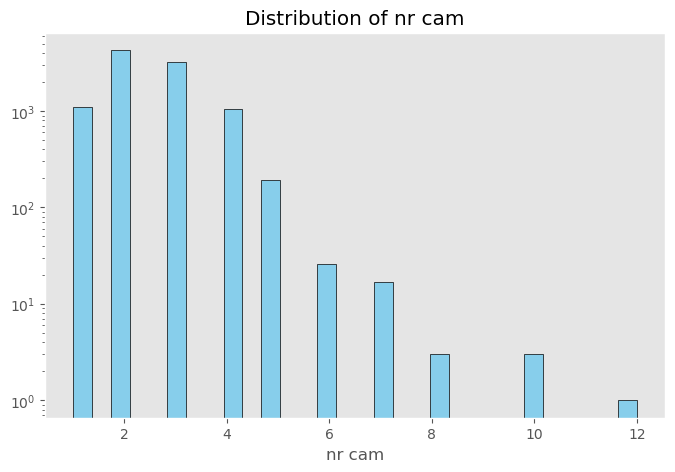

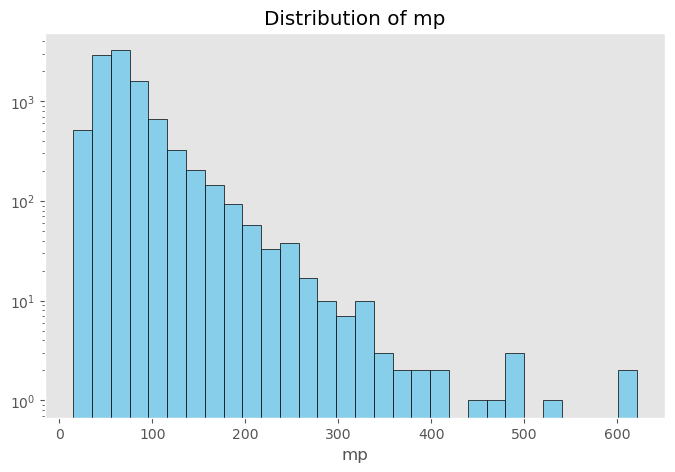

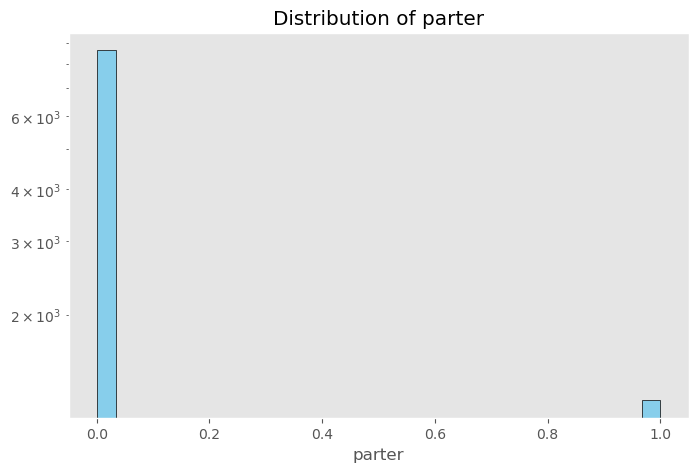

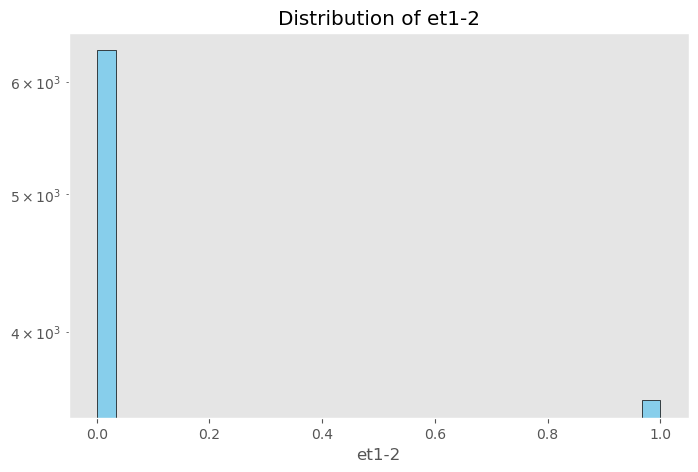

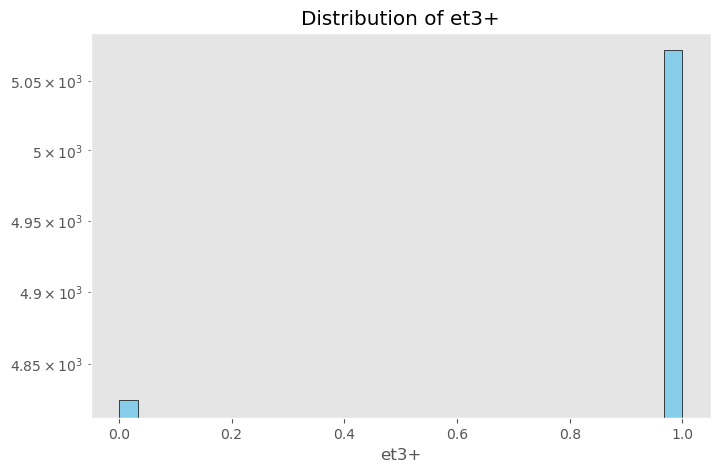

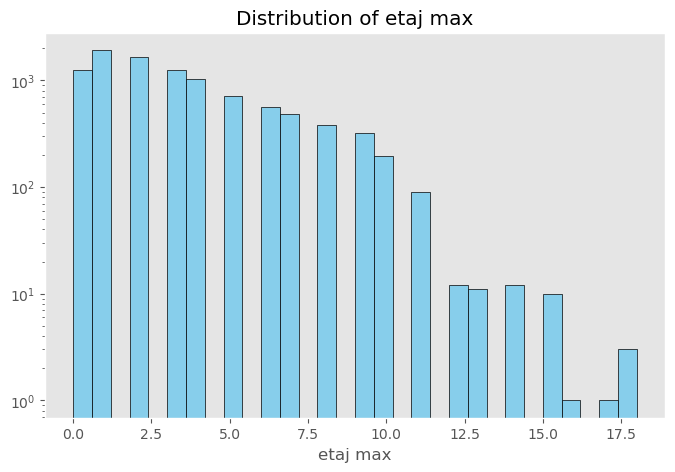

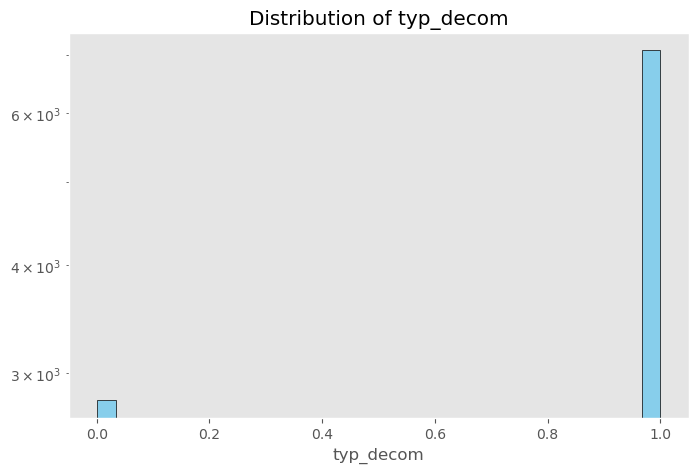

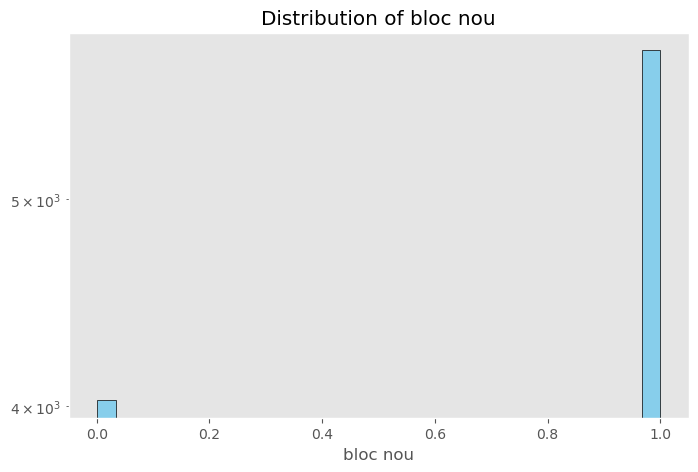

In [12]:
for col in X.columns:
    plot_feature_distrib(col, log=True)

In [13]:
X.corr()


,nr cam,mp,parter,et1-2,et3+,etaj max,typ_decom,bloc nou
nr cam,1.000000,0.777186,0.003816,-0.067465,0.062328,0.073172,-0.000365,-0.139376
mp,0.777186,1.000000,0.000869,-0.056167,0.053421,0.065719,0.087754,0.006321
parter,0.003816,0.000869,1.000000,-0.285501,-0.388748,-0.448826,0.004277,-0.002453
et1-2,-0.067465,-0.056167,-0.285501,1.000000,-0.772008,-0.500485,0.065535,0.187789
et3+,0.062328,0.053421,-0.388748,-0.772008,1.000000,0.778814,-0.065839,-0.178905
etaj max,0.073172,0.065719,-0.448826,-0.500485,0.778814,1.000000,-0.071077,-0.193046
typ_decom,-0.000365,0.087754,0.004277,0.065535,-0.065839,-0.071077,1.000000,0.213843
bloc nou,-0.139376,0.006321,-0.002453,0.187789,-0.178905,-0.193046,0.213843,1.000000


In [14]:
df.columns

Index(['Unnamed: 0', 'nr cam', 'mp', 'parter', 'et1-2', 'et3+', 'etaj max', 'typ_decom', 'bloc nou', 'Price/Surface', 'Price', 'WebPage'], dtype='object')

In [15]:
selected_columns = ['nr cam', 'mp', 'parter', 'et1-2', 'et3+', 'etaj max', 'typ_decom', 'bloc nou', 'Price']
df[selected_columns].corr()

,nr cam,mp,parter,et1-2,et3+,etaj max,typ_decom,bloc nou,Price
nr cam,1.000000,0.777186,0.003816,-0.067465,0.062328,0.073172,-0.000365,-0.139376,0.525333
mp,0.777186,1.000000,0.000869,-0.056167,0.053421,0.065719,0.087754,0.006321,0.770386
parter,0.003816,0.000869,1.000000,-0.285501,-0.388748,-0.448826,0.004277,-0.002453,-0.020806
et1-2,-0.067465,-0.056167,-0.285501,1.000000,-0.772008,-0.500485,0.065535,0.187789,-0.061217
et3+,0.062328,0.053421,-0.388748,-0.772008,1.000000,0.778814,-0.065839,-0.178905,0.072650
etaj max,0.073172,0.065719,-0.448826,-0.500485,0.778814,1.000000,-0.071077,-0.193046,0.091064
typ_decom,-0.000365,0.087754,0.004277,0.065535,-0.065839,-0.071077,1.000000,0.213843,0.034928
bloc nou,-0.139376,0.006321,-0.002453,0.187789,-0.178905,-0.193046,0.213843,1.000000,0.035021
Price,0.525333,0.770386,-0.020806,-0.061217,0.072650,0.091064,0.034928,0.035021,1.000000


## TODO: 

Create a "one-hot" predictor based on the "zone" feature extracted from the URL then re-compute the correlation matrix determining which zones are more expensive than others.

# Modeling

## Start with a simple linear regression model

Naively we aim to solve `X * w  + b = y` => w = ? 
X_bias  <- [X | 1]
=> Normal equation `w = (X^T*X)^(-1) * X^T *y`

X = m lines x n features = [M, N]
y = [M, 1]

X^TX = [N, M] * [M, N] = [N, N] => square matrix => inverted => [N, N]
[N, N] * [N, M] = [N, M]
[N, M] * [M, 1] = [N, 1] => w

Final reqularization step:
w = (X^T*X + λI)^(-1) * X^T *y


## Next steps:
### Continue with simple neural graph model
#### Enhance the model via grid search

In [52]:
def test_linear_model(X, y, weights, y_scale=None):
    y_pred = X.dot(weights)
    if y_scale is not None:
      y_min, y_max = y_scale
      y_pred = y_pred * (y_max - y_min) + y_min # reverse of y_min_max_normed = (y - y_min) / (y_max - y_min)
      y = y * (y_max - y_min) + y_min 
    residuals = y - y_pred
    err_prc = np.abs(residuals) / y
    mse = (residuals ** 2).mean()
    df_test = pd.DataFrame({'Actual': y, 'Predicted': y_pred, 'Residuals': residuals, 'ErrPrc': err_prc * 100})
    print(df_test.head(10))
    print(df_test.tail(10))
    print(f'Mean Squared Error: {mse}')
    print(f"Mean percentual error: {err_prc.mean() * 100:.1f}%")
    return mse

In [17]:
np_X = X.values
np_X

array([[  2.  ,  56.  ,   0.  ,   1.  ,   0.  ,   2.  ,   1.  ,   1.  ],
       [  2.  ,  57.  ,   0.  ,   1.  ,   0.  ,   2.  ,   0.  ,   1.  ],
       [  2.  ,  67.  ,   0.  ,   1.  ,   0.  ,   2.  ,   1.  ,   1.  ],
       [  1.  ,  48.  ,   0.  ,   1.  ,   0.  ,   2.  ,   1.  ,   1.  ],
       [  3.  ,  89.6 ,   0.  ,   0.  ,   1.  ,   3.  ,   1.  ,   1.  ],
       [  2.  ,  65.  ,   0.  ,   1.  ,   0.  ,   2.  ,   1.  ,   1.  ],
       [  2.  ,  46.  ,   0.  ,   0.  ,   1.  ,   4.  ,   1.  ,   1.  ],
       [  6.  , 334.  ,   0.  ,   0.  ,   1.  ,  10.  ,   1.  ,   1.  ],
       [  3.  , 104.26,   0.  ,   0.  ,   1.  ,  11.  ,   1.  ,   1.  ],
       [  2.  ,  65.  ,   0.  ,   1.  ,   0.  ,   1.  ,   0.  ,   1.  ],
       [  2.  ,  46.  ,   0.  ,   0.  ,   1.  ,   3.  ,   1.  ,   1.  ],
       [  1.  ,  43.02,   1.  ,   0.  ,   0.  ,   0.  ,   1.  ,   1.  ],
       [  3.  ,  80.23,   0.  ,   0.  ,   1.  ,   3.  ,   1.  ,   1.  ],
       [  1.  ,  30.  ,   1.  ,   0.  ,   0.  ,   0

In [18]:
np_X_b = np.concatenate([np_X, np.ones((np_X.shape[0], 1))], axis=1)
np_X_b

array([[  2.  ,  56.  ,   0.  ,   1.  ,   0.  ,   2.  ,   1.  ,   1.  ,   1.  ],
       [  2.  ,  57.  ,   0.  ,   1.  ,   0.  ,   2.  ,   0.  ,   1.  ,   1.  ],
       [  2.  ,  67.  ,   0.  ,   1.  ,   0.  ,   2.  ,   1.  ,   1.  ,   1.  ],
       [  1.  ,  48.  ,   0.  ,   1.  ,   0.  ,   2.  ,   1.  ,   1.  ,   1.  ],
       [  3.  ,  89.6 ,   0.  ,   0.  ,   1.  ,   3.  ,   1.  ,   1.  ,   1.  ],
       [  2.  ,  65.  ,   0.  ,   1.  ,   0.  ,   2.  ,   1.  ,   1.  ,   1.  ],
       [  2.  ,  46.  ,   0.  ,   0.  ,   1.  ,   4.  ,   1.  ,   1.  ,   1.  ],
       [  6.  , 334.  ,   0.  ,   0.  ,   1.  ,  10.  ,   1.  ,   1.  ,   1.  ],
       [  3.  , 104.26,   0.  ,   0.  ,   1.  ,  11.  ,   1.  ,   1.  ,   1.  ],
       [  2.  ,  65.  ,   0.  ,   1.  ,   0.  ,   1.  ,   0.  ,   1.  ,   1.  ],
       [  2.  ,  46.  ,   0.  ,   0.  ,   1.  ,   3.  ,   1.  ,   1.  ,   1.  ],
       [  1.  ,  43.02,   1.  ,   0.  ,   0.  ,   0.  ,   1.  ,   1.  ,   1.  ],
       [  3.  ,  80.23,   0.

In [19]:
np_w1 = np.linalg.pinv(np_X_b.T.dot(np_X_b)).dot(np_X_b.T).dot(y_price)
np_w1


array([-35253.17,   4068.76, -19653.11, -19536.64, -18810.11,   2762.81, -18637.49,   7934.74, -57999.86])

In [54]:
test_linear_model(np_X_b, y_price, np_w1)

    Actual     Predicted     Residuals      ErrPrc
0    35800  7.463073e+04 -3.883073e+04  108.465717
1    35800  9.733697e+04 -6.153697e+04  171.890991
2    39600  1.193871e+05 -7.978711e+04  201.482605
3    29800  7.733379e+04 -4.753379e+04  159.509376
4   112900  1.795773e+05 -6.667732e+04   59.058741
5    37400  1.112496e+05 -7.384959e+04  197.458789
6    39500  4.019526e+04 -6.952581e+02    1.760147
7  2350000  1.087563e+06  1.262437e+06   53.720724
8   332000  2.613279e+05  7.067215e+04   21.286792
9    39900  1.271243e+05 -8.722426e+04  218.607176
      Actual      Predicted     Residuals      ErrPrc
9887   47000   43077.370160   3922.629840    8.346021
9888   34500  -28458.867164  62958.867164  182.489470
9889   56000   28301.022572  27698.977428   49.462460
9890  101000  139730.923152 -38730.923152   38.347449
9891   79524   88871.394641  -9347.394641   11.754181
9892   85000  170468.449821 -85468.449821  100.551117
9893  134999  166740.318014 -31741.318014   23.512262
9894   

12333288996.96286

In [21]:
X.describe()

,nr cam,mp,parter,et1-2,et3+,etaj max,typ_decom,bloc nou
count,9897.000000,9897.000000,9897.000000,9897.000000,9897.000000,9897.000000,9897.000000,9897.00000
mean,2.505709,73.704865,0.125695,0.361827,0.512479,3.336466,0.717591,0.59321
std,0.950467,40.174869,0.331522,0.480553,0.499870,2.818757,0.450194,0.49126
min,1.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2.000000,51.800000,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000
50%,2.000000,64.000000,0.000000,0.000000,1.000000,3.000000,1.000000,1.00000
75%,3.000000,83.000000,0.000000,1.000000,1.000000,5.000000,1.000000,1.00000
max,12.000000,621.000000,1.000000,1.000000,1.000000,18.000000,1.000000,1.00000


In [26]:
np_X_n = (np_X - np.mean(np_X, axis=0)) / np.std(np_X, axis=0)
np_X_b_n = np.concatenate([np_X_n, np.ones((np_X_n.shape[0], 1))], axis=1)
np_X_b_n

array([[-0.53, -0.44, -0.38,  1.33, -1.03, -0.47,  0.63,  0.83,  1.  ],
       [-0.53, -0.42, -0.38,  1.33, -1.03, -0.47, -1.59,  0.83,  1.  ],
       [-0.53, -0.17, -0.38,  1.33, -1.03, -0.47,  0.63,  0.83,  1.  ],
       [-1.58, -0.64, -0.38,  1.33, -1.03, -0.47,  0.63,  0.83,  1.  ],
       [ 0.52,  0.4 , -0.38, -0.75,  0.98, -0.12,  0.63,  0.83,  1.  ],
       [-0.53, -0.22, -0.38,  1.33, -1.03, -0.47,  0.63,  0.83,  1.  ],
       [-0.53, -0.69, -0.38, -0.75,  0.98,  0.24,  0.63,  0.83,  1.  ],
       [ 3.68,  6.48, -0.38, -0.75,  0.98,  2.36,  0.63,  0.83,  1.  ],
       [ 0.52,  0.76, -0.38, -0.75,  0.98,  2.72,  0.63,  0.83,  1.  ],
       [-0.53, -0.22, -0.38,  1.33, -1.03, -0.83, -1.59,  0.83,  1.  ],
       [-0.53, -0.69, -0.38, -0.75,  0.98, -0.12,  0.63,  0.83,  1.  ],
       [-1.58, -0.76,  2.64, -0.75, -1.03, -1.18,  0.63,  0.83,  1.  ],
       [ 0.52,  0.16, -0.38, -0.75,  0.98, -0.12,  0.63,  0.83,  1.  ],
       [-1.58, -1.09,  2.64, -0.75, -1.03, -1.18,  0.63,  0.83, 

In [36]:
np_w2 = np.linalg.pinv(np_X_b_n.T.dot(np_X_b_n)).dot(np_X_b_n.T).dot(y_price)
np_w2

array([-33505.29, 163453.73,   2879.18,   3496.39,   4061.08,   7787.29,  -8390.06,   3897.82, 134925.49])

In [38]:
test_linear_model(np_X_b_n, y_price, np_w2)

   Actual      Predicted     Residuals
0   35800   74376.432656 -38576.432656
1   35800   97082.680837 -61282.680837
2   39600  119132.817744 -79532.817744
3   29800   77079.499907 -47279.499907
4  112900  179445.068462 -66545.068462
      Actual      Predicted     Residuals
9892   85000  170336.199931 -85336.199931
9893  134999  166608.068124 -31609.068124
9894   59000   58903.276317     96.723683
9895  110000  120633.769359 -10633.769359
9896   61500   30559.788629  30940.211371
Mean Squared Error: 12333524480.668766


12333524480.668766

## 2025-12-08

In [25]:
np_y_n = (y_price - y_price.min()) / (y_price.max() - y_price.min())
print(np_y_n.min(), np_y_n.max(), np_y_n.mean())

0.0 1.0 0.030275890690162528


In [29]:
np_w3 = np.linalg.pinv(np_X_b_n.T.dot(np_X_b_n)).dot(np_X_b_n.T).dot(np_y_n)
np_w3

array([-0.01,  0.04,  0.  ,  0.  ,  0.  ,  0.  , -0.  ,  0.  ,  0.03])

In [37]:
test_linear_model(np_X_b_n, np_y_n, np_w3)

     Actual  Predicted  Residuals
0  0.004609   0.014610  -0.010001
1  0.004609   0.020490  -0.015881
2  0.005593   0.026199  -0.020606
3  0.003055   0.015310  -0.012255
4  0.024573   0.041804  -0.017231
        Actual  Predicted  Residuals
9892  0.017349   0.039445  -0.022097
9893  0.030295   0.038480  -0.008185
9894  0.010616   0.010591   0.000025
9895  0.023822   0.026576  -0.002754
9896  0.011264   0.003252   0.008011
Mean Squared Error: 0.0008269149390842848


0.0008269149390842848

In [39]:
test_linear_model(np_X_b_n, np_y_n, np_w3, y_scale=(y_price.min(), y_price.max()))

     Actual      Predicted     Residuals
0   35800.0   74425.079294 -38625.079294
1   35800.0   97131.327476 -61331.327476
2   39600.0  119181.464383 -79581.464383
3   29800.0   77128.146545 -47328.146545
4  112900.0  179446.150310 -66546.150310
        Actual      Predicted     Residuals
9892   85000.0  170337.281779 -85337.281779
9893  134999.0  166609.149971 -31610.149971
9894   59000.0   58904.358164     95.641836
9895  110000.0  120634.851206 -10634.851206
9896   61500.0   30560.870476  30939.129524
Mean Squared Error: 12333472700.699427


12333472700.699427

In [44]:
np_w4 = np.linalg.inv(np_X_b_n.T.dot(np_X_b_n) + 0.1 * np.eye(np_X_n.shape[1] + 1)).dot(np_X_b_n.T).dot(np_y_n)
np_w4

array([-0.01,  0.04, -0.  , -0.  ,  0.  ,  0.  , -0.  ,  0.  ,  0.03])

In [53]:
test_linear_model(np_X_b_n, np_y_n, np_w4, y_scale=(y_price.min(), y_price.max()))

      Actual     Predicted     Residuals      ErrPrc
0    35800.0  7.463001e+04 -3.883001e+04  108.463711
1    35800.0  9.733518e+04 -6.153518e+04  171.885983
2    39600.0  1.193850e+05 -7.978500e+04  201.477276
3    29800.0  7.732950e+04 -4.752950e+04  159.494981
4   112900.0  1.795773e+05 -6.667726e+04   59.058689
5    37400.0  1.112477e+05 -7.384773e+04  197.453823
6    39500.0  4.019612e+04 -6.961157e+02    1.762318
7  2350000.0  1.087546e+06  1.262454e+06   53.721463
8   332000.0  2.613258e+05  7.067421e+04   21.287412
9    39900.0  1.271215e+05 -8.722148e+04  218.600190
        Actual      Predicted     Residuals      ErrPrc
9887   47000.0   43073.777525   3926.222475    8.353665
9888   34500.0  -28457.743980  62957.743980  182.486214
9889   56000.0   28301.705900  27698.294100   49.461239
9890  101000.0  139728.179995 -38728.179995   38.344733
9891   79524.0   88870.233458  -9346.233458   11.752721
9892   85000.0  170470.808022 -85470.808022  100.553892
9893  134999.0  166739.67

12333289008.248774

# Conclusions so far

- with all the bells and whistles we can reach a better error than 40% (mean absolute percentage error)
- we need now to squeeze as much salient features as possible from the data

In [55]:
df['Location'] = df["WebPage"].apply(lambda x: x.split('/')[5])
df['Location']

0                   rahova
1                   rahova
2                   rahova
3                   rahova
4       p-ta-presei-libere
               ...        
9892              crangasi
9893               central
9894              apusului
9895       theodor-pallady
9896           politehnica
Name: Location, Length: 9897, dtype: object

In [56]:
df_new = pd.get_dummies(df['Location'], prefix="L", columns=['Location'], dtype=np.uint8)
df_new


,L_1-decembrie-1918,L_1-mai,L_13-septembrie,L_16-februarie,L_agronomie,L_alba-iulia,L_alexandriei,L_alexandru-obregia,L_andronache,L_antiaeriana,L_aparatorii-patriei,L_apusului,L_arcul-de-triumf,L_armeneasca,L_aviatiei,L_aviatorilor,L_baba-novac,L_baicului,L_balta-alba,L_baneasa,L_banu-manta,L_barbu-vacarescu,L_basarab,L_basarabia,L_batistei,L_bd-gloriei,L_beller,L_berceni,L_brancoveanu,L_bucur-obor,L_bucurestii-noi,L_calea-calarasilor,L_calea-plevnei,L_calea-victoriei,L_camil-ressu,L_campia-libertatii,L_cantemir,L_capitale,L_casin,L_central,L_centrul-civic,L_centrul-istoric,L_chibrit,L_chisinau,L_chitila,L_cismigiu,L_clabucet,L_clucerului,L_colentina,L_compozitorilor,L_constructorilor,L_cosbuc,L_costin-georgian,L_cotroceni,L_crangasi,L_dacia,L_damaroaia,L_decebal,L_doamna-ghica,L_domenii,L_dorobanti,L_dristor,L_drumul-gazarului,L_drumul-sarii,L_drumul-taberei,L_dudesti,L_eminescu,L_eroii-revolutiei,L_ferdinand,L_ferentari,L_fizicienilor,L_floreasca,L_foisorul-de-foc,L_fundeni,L_gara-de-nord,L_ghencea,L_giulesti,L_giurgiului,L_gorjului,L_gradina-icoanei,L_grivita,L_grozavesti,L_herastrau,L_iancu-nicolae,L_iancului,L_jiului,L_kiseleff,L_kogalniceanu,L_lacul-morii,L_lacul-tei,L_lahovari,L_libertatii,L_liviu-rebreanu,L_lucretiu-patrascanu,L_lujerului,L_macaralei,L_magheru,L_marasesti,L_margeanului,L_matei-voievod,L_metalurgiei,L_mihai-bravu,L_militari,L_morarilor,L_mosilor,L_muncii,L_natiunile-unite,L_nerva-traian,L_nicolae-grigorescu,L_nord,L_nordului,L_obor,L_octavian-goga,L_oltenitei,L_ozana,L_p-ta-alba-iulia,L_p-ta-amzei,L_p-ta-dorobanti,L_p-ta-gorjului,L_p-ta-muncii,L_p-ta-presei-libere,L_p-ta-resita,L_p-ta-romana,L_p-ta-rosetti,L_p-ta-sfanta-vineri,L_p-ta-unirii,L_p-ta-universitatii,L_p-ta-victoriei,L_pache-protopopescu,L_pacii,L_pajura,L_panduri,L_pantelimon,L_parcul-carol,L_parcul-circului,L_pipera,L_plevnei,L_politehnica,L_polona,L_prelungirea-ghencea,L_primaverii,L_progresul,L_rahova,L_regie,L_regina-elisabeta,L_romana,L_rosetti,L_sala-palatului,L_salaj,L_salajan,L_sebastian,L_serban-voda,L_sisesti,L_socului,L_soseaua-nordului,L_splaiul-independentei,L_splaiul-unirii,L_stefan-cel-mare,L_stirbei-voda,L_straulesti,L_sud,L_sud-est,L_tei,L_teiul-doamnei,L_televiziune,L_theodor-pallady,L_timisoara,L_timpuri-noi,L_tineretului,L_titan,L_titulescu,L_trafic-greu,L_turda,L_ultracentral,L_unirii,L_universitate,L_uverturii,L_vacaresti,L_valea-ialomitei,L_valea-oltului,L_vatra-luminoasa,L_veteranilor,L_victoriei,L_viilor,L_virtutii,L_vitan,L_vitan-barzesti,L_vitan-mall,L_vitanul-nou,L_zetarilor
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

In [58]:
np_loc = df_new.values
np_X_n_l = np.concatenate((np_X_n, np_loc), axis=1)
np_X_n_l.shape

(9897, 198)

In [62]:
np_X_n_l_b = np.concatenate((np_X_n_l, np.ones((np_X_n.shape[0], 1))), axis=1)
np_X_n_l_b.shape

(9897, 199)

# TODO:
  - check the correlation matrix now using `df_loc` + `Price` column`
  - recalculate the weights of a linear regression and check the error

# 2025-12-15